# Project 3: Object Detection with Pretrained Models
### Applied Deep Learning

**Student Name:** Jorgeandres Alvarez  
**Date:** 3/24/2026

---
> **Instructions:** Complete each task by writing your code in the empty cells provided. Read the description above each cell carefully before starting. Do not delete any Markdown cells. When you are done,  Submit a **PDF** export. You run all cells first, then go to File → Print → Save as PDF. This captures all code, output, and inline images in one clean file.

---
## Task 1 — Load Pretrained Model (15 pts)

In this cell, you need to:
1. Load the pretrained YOLOv8 nano model using `YOLO('yolov8n.pt')` — it will download automatically (~6MB) if not already cached
2. Print the total number of classes the model can detect
3. Print all class names (there should be 80 — these are the COCO categories)

>  **Hint:** After loading the model, the class names are stored in `model.names` as a dictionary `{id: name}`

In [2]:
!pip install -q ultralytics
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
num_classes = len(model.names)
print(f"Total number of classes: {num_classes}")

print("Class names:")
for class_id, class_name in model.names.items():
    print(f"{class_id}: {class_name}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 22.0 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Total number of classes: 80
Class names:
0: person
1: bicycle
2: car
3: motorcycle
4: airplane
5: bus
6: train
7: truck
8: boat
9: traffic light
10: fire hydrant
11: stop sign
12: parking meter
13: bench
14: bird
15: cat
16: dog
17: horse
18: sheep
19: cow
20: elephant
21: bear
22: zebra
23: giraffe
24: backpack
25: umbrella
26: handbag
27: tie
28: suitcase
29: frisbee
30: skis
31: snowboard
32: sports ball
33: kite
34: baseball bat
35: baseball glove
36: skateboard
37: surfboard
38: tennis racket
39: bottle
40: wine glass
41: cup
42: fork
43: knife
44: spoon
45: bowl
46: banana
47: apple
48: sandwich
49:

---
## Task 2 — Choose and Display Your Image (15 pts)

### Step 1 — Justify your image choice

In the Markdown cell below, explain:
- What image you chose and where it is from
- Which objects (at least 3) you expect the model to detect

The image I chose is a candid photo from the city of New York. It includes several people crossing a walkway in a bustling city. There is a lot going on and some parts of the image will be harder to decipher than others.

I expect the model to detect several people, the cars, and some handbags that are visible. I am interested to see if the model will be able to detect the straps of the back pack on the man in the bottom right corner of the image. I am also interested in seeing what the model will classify the statue as.  

### Step 2 — Load and display your image

In this cell, you need to:
1. Load your chosen image — use **one** of the two options below:
   - **Option A (URL):** Use `urllib.request.urlretrieve(url, filename)` to download an image from the web
   - **Option B (Upload):** Use `from google.colab import files` then `files.upload()` to upload a file from your computer
2. Read the image with `cv2.imread()` and convert it from BGR to RGB using `cv2.cvtColor()`
3. Print the image dimensions: height, width, and number of channels
4. Display the image using `matplotlib` with the title `"My Test Image"`

>  **Requirement:** Your image must contain at least 3 objects from the COCO class list printed in Task 1.

>  **Hint:** OpenCV loads images in BGR format. Convert to RGB before displaying with matplotlib: `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)`

Image dimensions: height=1015, width=1300, channels=3


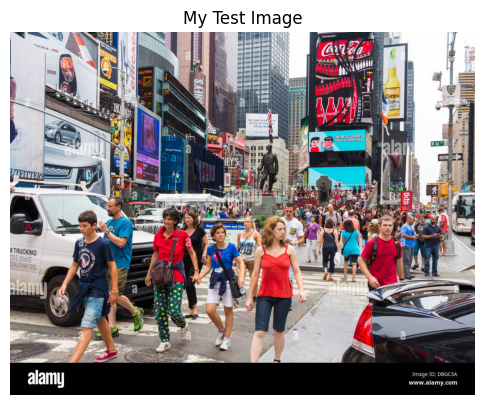

In [3]:
# Task 2 — Your code here

import urllib.request
import cv2
import matplotlib.pyplot as plt

IMAGE_URL = "https://c8.alamy.com/comp/DBGC3A/busy-times-square-in-manhattan-new-york-city-street-with-crowds-of-DBGC3A.jpg"
IMAGE_PATH = "my_test_image.jpg"
urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

img_bgr = cv2.imread(IMAGE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

height, width, channels = img_rgb.shape
print(f"Image dimensions: height={height}, width={width}, channels={channels}")

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.title("My Test Image")
plt.axis("off")
plt.show()


---
## Task 3 — Run Object Detection (35 pts)

In this cell, you need to:
1. Run the model on your image using `model(IMAGE_PATH, conf=0.25, verbose=False)` — the `conf` parameter sets the minimum confidence threshold
2. Extract the detections from `results[0].boxes`
3. Print the **total number of objects** detected
4. For **each detected object**, print:
   - The class name (look it up using `model.names[class_id]`)
   - The confidence score, rounded to 2 decimal places
   - The bounding box coordinates `(x1, y1, x2, y2)` — use `box.xyxy[0].tolist()`
5. Print a summary showing how many objects were found per class

>  **Hint:** For each `box` in `result.boxes`, you can get the class id with `int(box.cls[0])` and confidence with `float(box.conf[0])`

>  **Hint:** If fewer than 3 objects are detected, try lowering the confidence threshold to `conf=0.2`

In [4]:
# Task 3 — Your code here

# 1. Run the model on your image
results = model(IMAGE_PATH, conf=0.25, verbose=False)
result = results[0]
boxes = result.boxes

# 2. Extract detections
num_detections = len(boxes)
print(f"Total number of objects detected: {num_detections}")

# 3–4. Print details for each detected object
from collections import defaultdict

class_counts = defaultdict(int)

for i, box in enumerate(boxes):
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    class_counts[class_name] += 1

    print(f"Detection {i+1}:")
    print(f"  Class: {class_name} (id={class_id})")
    print(f"  Confidence: {confidence:.2f}")
    print(f"  Box (x1, y1, x2, y2): ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")

# 5. Summary: how many objects per class
print("\nSummary: objects per class")
for cls_name, count in class_counts.items():
    print(f"  {cls_name}: {count}")


Total number of objects detected: 26
Detection 1:
  Class: person (id=0)
  Confidence: 0.88
  Box (x1, y1, x2, y2): (657.4, 525.6, 826.4, 917.7)
Detection 2:
  Class: person (id=0)
  Confidence: 0.88
  Box (x1, y1, x2, y2): (129.8, 500.4, 303.6, 924.0)
Detection 3:
  Class: person (id=0)
  Confidence: 0.85
  Box (x1, y1, x2, y2): (508.4, 532.8, 660.4, 894.6)
Detection 4:
  Class: person (id=0)
  Confidence: 0.77
  Box (x1, y1, x2, y2): (377.5, 494.6, 521.9, 896.8)
Detection 5:
  Class: person (id=0)
  Confidence: 0.75
  Box (x1, y1, x2, y2): (262.5, 462.7, 347.6, 841.2)
Detection 6:
  Class: person (id=0)
  Confidence: 0.73
  Box (x1, y1, x2, y2): (1140.1, 513.9, 1208.8, 686.6)
Detection 7:
  Class: person (id=0)
  Confidence: 0.73
  Box (x1, y1, x2, y2): (971.7, 513.1, 1103.7, 721.6)
Detection 8:
  Class: bus (id=5)
  Confidence: 0.69
  Box (x1, y1, x2, y2): (1231.5, 433.5, 1299.4, 573.9)
Detection 9:
  Class: person (id=0)
  Confidence: 0.57
  Box (x1, y1, x2, y2): (864.4, 523.2, 923

---
## Task 4 — Visualize Results (35 pts)

In this cell, you need to:
1. Create a copy of your original image to draw on (use `.copy()` so you don't modify the original)
2. For each detected object, draw:
   - A **bounding box** rectangle around the object using `cv2.rectangle()`
   - A **label** showing the class name and confidence score using `cv2.putText()`
   - A filled rectangle behind the label text so it is readable
3. Use a **different color per class** — you can assign colors using `np.random.seed(42)` for reproducibility
4. Display the annotated image using `matplotlib` with the title `"YOLOv8 Object Detection Results"`
5. Print a confirmation message with the total number of annotated objects

>  **Hint:** `cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)` draws a rectangle. Use `thickness=-1` to fill it.

>  **Hint:** OpenCV uses BGR color order, but since you converted your image to RGB, pass colors as `(R, G, B)` tuples.

>  **Alternative:** You can also use `result.plot()` which returns an annotated image directly — this is acceptable for full credit.

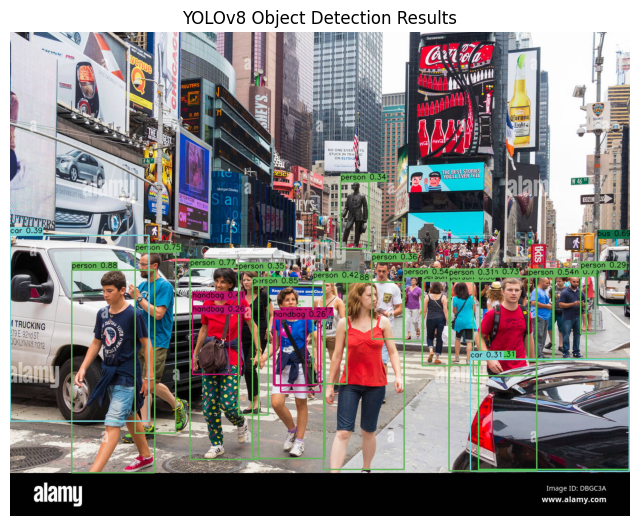

Total number of annotated objects: 26


In [5]:
# Task 4 — Your code here

import numpy as np
import matplotlib.pyplot as plt
import cv2

boxes = result.boxes

# 1. Create a copy of the original RGB image
annotated_img = img_rgb.copy()

#Define a different color per class
np.random.seed(42)
class_colors = {}

# 2. Draw bounding boxes and labels
annotated_count = 0
for box in boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0])
    x1, y1, x2, y2 = box.xyxy[0].tolist()

    # 3. Get color for this class, or create a new one
    if class_id not in class_colors:
        color = tuple(np.random.randint(0, 256, size=3).tolist())  # (R, G, B)
        class_colors[class_id] = color
    else:
        color = class_colors[class_id]

    # Convert coordinates to integers
    x1_i, y1_i, x2_i, y2_i = map(int, [x1, y1, x2, y2])

    # Draw bounding box
    cv2.rectangle(annotated_img, (x1_i, y1_i), (x2_i, y2_i), color, thickness=2)

    # Prepare label text
    label = f"{class_name} {confidence:.2f}"

    # Compute label background size
    (text_width, text_height), baseline = cv2.getTextSize(
        label, cv2.FONT_HERSHEY_SIMPLEX, fontScale=0.5, thickness=1
    )

    # Top-left corner for the text background
    label_x1 = x1_i
    label_y1 = y1_i - text_height - baseline
    label_x2 = x1_i + text_width
    label_y2 = y1_i

    # Ensure label background is within image
    label_y1 = max(label_y1, 0)

    # Draw filled rectangle behind text
    cv2.rectangle(
        annotated_img,
        (label_x1, label_y1),
        (label_x2, label_y2),
        color,
        thickness=-1,
    )

    # Draw text (black or white depending on color; using white here)
    cv2.putText(
        annotated_img,
        label,
        (label_x1, label_y2 - baseline),
        cv2.FONT_HERSHEY_SIMPLEX,
        fontScale=0.5,
        color=(0, 0, 0),
        thickness=1,
        lineType=cv2.LINE_AA,
    )

    annotated_count += 1

# 4. Display annotated image
plt.figure(figsize=(8, 8))
plt.imshow(annotated_img)
plt.title("YOLOv8 Object Detection Results")
plt.axis("off")
plt.show()

# 5. Confirmation message
print(f"Total number of annotated objects: {annotated_count}")


After investigation of the annotated image, I can declare that it gave a very good response to classifying parts of the image. It did classify the statue as a person and it was able to analyze two of the cars in the foreground of the image. However, it did not classify the cars in the advertisements as cars. Furthermore, it did not classify the man's backpack through his straps which makes sense as these could be classified as part of the person's clothing. Something else that is notable is that it duplicated the number of classified handbags that it was able to find. So instead of seeing only two, it turned it into four. Finally, the model classified a boat somewhere in the image, but after careful inspection I am unable to deduce where this boat is being seen.